# 02 — Signal Validation (No-Lookahead Backtest)
Backtests the Skins Market signals with **signal-at-close[t] → return[t+1]** convention.


In [68]:
import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 200)


## 1) Load & standardize data

In [69]:
import numpy as np
import pandas as pd

def load_and_standardize_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    # Handle alternate close naming
    if "Latest" in df.columns and "Close" not in df.columns:
        df = df.rename(columns={"Latest": "Close"})

    # Parse datetime robustly (coerce bad rows -> NaT -> drop)
    if "Time" in df.columns:
        dt = pd.to_datetime(df["Time"], errors="coerce")
        df = df.assign(Date=dt).dropna(subset=["Date"]).sort_values("Date").set_index("Date")
    elif "Date" in df.columns:
        dt = pd.to_datetime(df["Date"], errors="coerce")
        df = df.assign(Date=dt).dropna(subset=["Date"]).sort_values("Date").set_index("Date")
    else:
        raise ValueError("CSV must contain a Time or Date column")

    # Standardize column names to lowercase where expected
    ren = {k: k.lower() for k in ["Open", "High", "Low", "Close", "Volume", "Change"] if k in df.columns}
    df = df.rename(columns=ren)

    # Numeric coercion (helps strip footer rows / stray strings)
    for c in ["open", "high", "low", "close", "volume", "change"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Drop any rows that still don't have a close
    if "close" not in df.columns:
        raise ValueError("Need close prices. Column Close/Latest missing.")
    df = df.dropna(subset=["close"])

    # Build returns (prefer Barchart-style 'Change' if present)
    if "change" in df.columns and df["change"].notna().any():
        df["prev_close"] = df["close"] - df["change"]
        df["ret"] = df["close"] / df["prev_close"] - 1.0
    else:
        df["ret"] = df["close"].pct_change()

    # Clean volume
    if "volume" in df.columns:
        df["volume"] = df["volume"].replace(0, np.nan).ffill()

    return df


DATA_PATH = r"C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\data\raw\qqq_train_validation.csv"
df = load_and_standardize_csv(DATA_PATH)
df.head()

C:\Users\brijp\AppData\Local\Temp\ipykernel_26192\952860129.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(df["Time"], errors="coerce")


,Time,open,high,low,close,change,%Change,volume,prev_close,ret
Date,,,,,,,,,,
2000-01-03,1/3/00,81.3772,81.3772,76.7749,80.1589,2.8552,3.69%,85922031,77.3037,0.036935
2000-01-04,1/4/00,77.8324,79.1014,74.3976,74.6599,-5.4990,-6.86%,79873331,80.1589,-0.068601
2000-01-05,1/5/00,74.0254,75.8232,71.2759,72.7564,-1.9035,-2.55%,100464224,74.6599,-0.025496
2000-01-06,1/6/00,73.4966,74.4484,67.4689,67.7607,-4.9957,-6.87%,87788706,72.7564,-0.068663
2000-01-07,1/7/00,70.1676,76.1404,69.7954,76.1404,8.3797,12.37%,66520215,67.7607,0.123666


## 2) Import signal functions

In [ ]:
import importlib.util
from pathlib import Path
import sys

SIGNALS_PATH = Path(r"C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\src\signals.py")

def import_signals_module(path: Path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Signals file not found: {path}")

    src_dir = str(path.parent)
    if src_dir not in sys.path:
        sys.path.insert(0, src_dir)

    spec = importlib.util.spec_from_file_location("signals_mod", str(path))
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)  # type: ignore
    print(f"Loaded signals module from: {path}")
    return mod

signals_mod = import_signals_module(SIGNALS_PATH)


sig_float_cap = signals_mod.sig_flow_float_cap_atr_compression
sig_market_crash = signals_mod.sig_flow_market_crash_vol_accel_fade
sig_market_bot = signals_mod.sig_flow_market_bot_volume_stability
sig_buy_order = signals_mod.sig_pa_buy_order_channel_position


Loaded signals module from: C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\src\signals.py


## 3) Build exposures (unshifted, then applied to next day returns)

In [ ]:
import inspect


strategies = {}
skipped = []

# signals_mod should be your imported module (from signals.py)
# df should already be standardized with lowercase columns: open/high/low/close/volume

for fname, fn in inspect.getmembers(signals_mod, inspect.isfunction):
    if not fname.startswith("sig_"):
        continue

    try:
        lev = fn(df)  # use defaults
        if not isinstance(lev, pd.Series):
            skipped.append((fname, "return type not pd.Series"))
            continue

        lev = lev.reindex(df.index).astype(float)
        lev = lev.replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(-1.0, 1.5)
        strategies[fname] = lev

    except Exception as e:
        skipped.append((fname, f"{type(e).__name__}: {e}"))

# Always include benchmark
strategies["Sig_BuyHold"] = pd.Series(1.0, index=df.index)

print(f"Loaded {len(strategies)} strategies.")
print(f"Skipped {len(skipped)} signal functions.")
# Show first few skip reasons (helpful debugging)
skipped[:10], list(strategies.keys())[:15]

strategies = {}
skipped = []


for fname, fn in inspect.getmembers(signals_mod, inspect.isfunction):
    if not fname.startswith("sig_"):
        continue

    try:
        lev = fn(df)  # use defaults
        if not isinstance(lev, pd.Series):
            skipped.append((fname, "return type not pd.Series"))
            continue

        lev = lev.reindex(df.index).astype(float)
        lev = lev.replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(-1.0, 1.5)
        strategies[fname] = lev

    except Exception as e:
        skipped.append((fname, f"{type(e).__name__}: {e}"))

strategies["Sig_BuyHold"] = pd.Series(1.0, index=df.index)

print(f"Loaded {len(strategies)} strategies.")
print(f"Skipped {len(skipped)} signal functions.")
list(strategies.keys())[:31]


Loaded 32 strategies.
Skipped 0 signal functions.
Loaded 32 strategies.
Skipped 0 signal functions.


['sig_benchmark_buy_hold',
 'sig_csgo_camp_fire',
 'sig_csgo_simple_mix',
 'sig_csgo_vol_regime',
 'sig_flow_float_cap_atr_compression',
 'sig_flow_market_bot_volume_stability',
 'sig_flow_market_crash_vol_accel_fade',
 'sig_linear_crossfire_filtered',
 'sig_linear_diversified',
 'sig_linear_wallhack_filtered',
 'sig_mr_crosshair_vt',
 'sig_mr_eco_fade',
 'sig_mr_gap_trap',
 'sig_mr_ibs_vt',
 'sig_mr_snap_revert',
 'sig_pa_buy_order_channel_position',
 'sig_season_allstar',
 'sig_season_calendar_alpha',
 'sig_season_holiday_drift',
 'sig_season_monday_effect',
 'sig_season_september_effect',
 'sig_season_turn_of_month',
 'sig_tail_wallbang_ath_drawdown',
 'sig_vol_camping',
 'sig_vol_decoy_gk_target',
 'sig_vol_molotov_downside_target',
 'sig_vol_rushb',
 'sig_vol_shiftwalk_target',
 'sig_vol_silence_bb_squeeze',
 'sig_vol_smoke_parkinson_target',
 'sig_vol_sneakybeaky_atr_target']

## 4) Backtest & metrics

In [72]:
def calc_metrics(daily_ret: pd.Series) -> dict:
    r = daily_ret.dropna()
    if len(r) == 0:
        return {'sharpe': 0.0, 'calmar': 0.0, 'total_ret': 0.0, 'max_dd': 0.0}
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0.0
    curve = (1 + r).cumprod()
    total_ret = curve.iloc[-1] - 1
    dd = (curve - curve.cummax()) / curve.cummax()
    max_dd = float(dd.min())
    calmar = ann_ret / abs(max_dd) if max_dd < 0 else np.nan
    return {'sharpe': float(sharpe), 'calmar': float(calmar) if np.isfinite(calmar) else np.nan, 'total_ret': float(total_ret), 'max_dd': max_dd}

def run_backtest(exposure: pd.Series, next_ret: pd.Series) -> pd.Series:
    return exposure * next_ret


In [73]:
df["next_ret"] = df["ret"].shift(-1)

df[["ret", "next_ret"]].tail()


,ret,next_ret
Date,,
2021-12-27,0.016527,-0.004635
2021-12-28,-0.004635,-0.000149
2021-12-29,-0.000149,-0.002988
2021-12-30,-0.002988,-0.006245
2021-12-31,-0.006245,NaN


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import sys

# -----------------------------
# 1) Make imports work reliably
# -----------------------------

PROJECT_ROOT = Path(r"C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from src.backtest_engine import backtest_leverage_signal
    from src.utils import annualized_sharpe, calmar_ratio, max_drawdown
except Exception:
    # Fallback: treat src/ as flat module directory
    SRC_DIR = PROJECT_ROOT / "src"
    if str(SRC_DIR) not in sys.path:
        sys.path.insert(0, str(SRC_DIR))

    from backtest_engine import backtest_leverage_signal
    from utils import annualized_sharpe, calmar_ratio, max_drawdown


# -----------------------------
# 2) Train/Test split
# -----------------------------
train_start, train_end = "2000-01-01", "2015-12-31"
test_start, test_end   = "2016-01-01", "2021-12-31"

def slice_stats(bt_slice: pd.DataFrame) -> dict:
    if bt_slice is None or len(bt_slice) == 0:
        return {"sharpe": 0.0, "calmar": 0.0, "ret": 0.0, "maxdd": 0.0, "n": 0}

    r = bt_slice["ret"].dropna()
    if len(r) == 0:
        return {"sharpe": 0.0, "calmar": 0.0, "ret": 0.0, "maxdd": 0.0, "n": 0}

    eq = (1.0 + r).cumprod()
    return {
        "sharpe": float(annualized_sharpe(r)),
        "calmar": float(calmar_ratio(r)),
        "ret": float(eq.iloc[-1] - 1.0),
        "maxdd": float(max_drawdown(eq)),
        "n": int(len(r)),
    }


# -----------------------------
# 3) Run backtests for ALL strategies
# -----------------------------
rows = []
curves = {}

for name, lev in strategies.items():
    bt_df, stats_full = backtest_leverage_signal(df, lev, name=name)

    bt_train = bt_df.loc[train_start:train_end]
    bt_test  = bt_df.loc[test_start:test_end]

    tr = slice_stats(bt_train)
    te = slice_stats(bt_test)

    rows.append({
        "Strategy": name,
        "Train Sharpe": tr["sharpe"],
        "Train Calmar": tr["calmar"],
        "Train Ret": tr["ret"],
        "Train MaxDD": tr["maxdd"],

        "Test Sharpe": te["sharpe"],
        "Test Calmar": te["calmar"],
        "Test Ret": te["ret"],
        "Test MaxDD": te["maxdd"],

        "n_days_full": int(stats_full.get("n_days", len(bt_df))),
        "avg_turnover": float(stats_full.get("avg_turnover", np.nan)),
    })

    curves[name] = bt_df["equity"]

results = (
    pd.DataFrame(rows)
      .set_index("Strategy")
      .sort_values("Test Sharpe", ascending=False)
)

print("Number of strategies tested:", len(results))
results.head(32)


Number of strategies tested: 32


,Train Sharpe,Train Calmar,Train Ret,Train MaxDD,Test Sharpe,Test Calmar,Test Ret,Test MaxDD,n_days_full,avg_turnover
Strategy,,,,,,,,,,
sig_csgo_simple_mix,0.350709,0.104531,1.083008,-0.449770,1.598686,1.819017,4.172819,-0.173481,5535,0.097995
sig_flow_float_cap_atr_compression,0.157361,0.021664,0.217405,-0.572044,1.510839,1.329451,1.234539,-0.108016,5535,0.018948
sig_csgo_vol_regime,0.304677,0.091364,0.946319,-0.465993,1.484002,1.546758,4.190993,-0.204515,5535,0.145592
sig_csgo_camp_fire,0.322775,0.096364,0.975501,-0.451901,1.378894,1.366501,3.903366,-0.222372,5535,0.053107
sig_vol_sneakybeaky_atr_target,0.453362,0.130293,1.048134,-0.352348,1.376880,1.399658,1.778299,-0.132844,5535,0.023601
sig_vol_rushb,0.075952,0.000702,0.007355,-0.653472,1.367443,1.358024,1.195331,-0.103260,5535,0.033966
sig_vol_camping,0.106056,-0.013409,-0.172072,-0.876504,1.334613,1.294314,3.472059,-0.219413,5535,0.034341
sig_vol_decoy_gk_target,0.487896,0.150849,2.052118,-0.479681,1.315760,1.258480,2.950317,-0.204755,5535,0.017234
sig_vol_silence_bb_squeeze,0.348865,0.094254,0.866887,-0.422886,1.315707,1.076714,1.715280,-0.168479,5535,0.038954


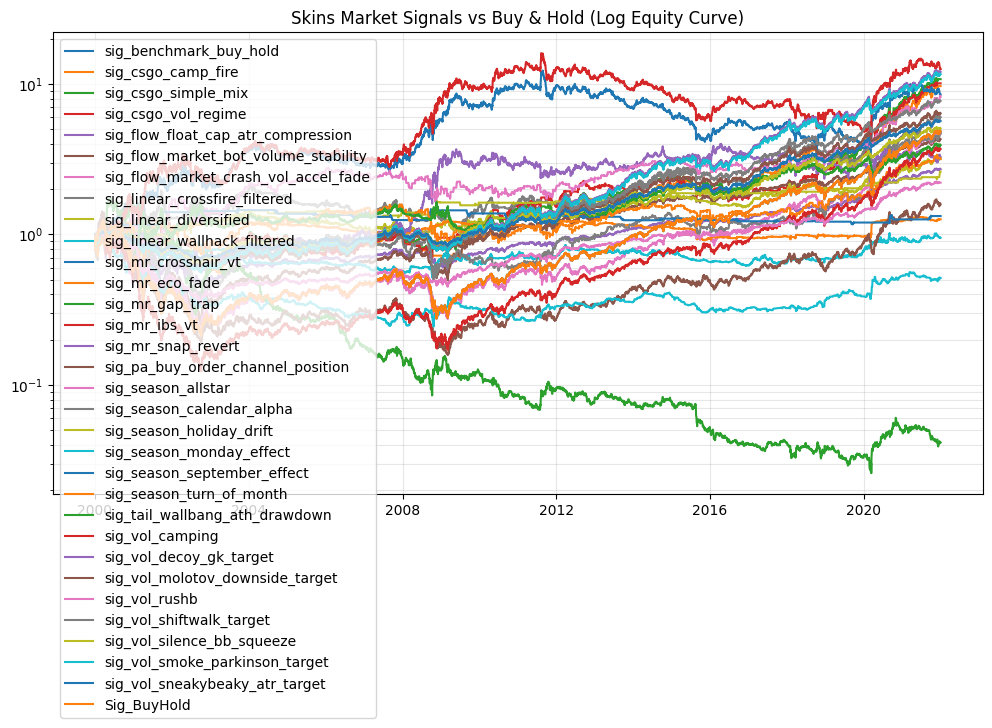

In [75]:
plt.figure(figsize=(12, 6))
for name, curve in curves.items():
    plt.plot(curve, label=name, linewidth=1.5)
plt.yscale('log')
plt.title('Skins Market Signals vs Buy & Hold (Log Equity Curve)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()